In [ ]:
# 🤖 Day 6 - Titanic Survival Prediction using Machine Learning

## About This Project
Building a Machine Learning model to predict who survived 
the Titanic disaster using passenger data.
This is my first ever ML model!

## Dataset
- 891 passengers, 12 columns
- Source: Real Titanic passenger data from 1912

## ML Workflow Used
## Algorithm Used
**Logistic Regression** — predicts probability of 
survival (0=died, 1=survived)

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df=pd.read_csv(url)

print('Data Loaded')
print(df.shape)

Data Loaded
(891, 12)


In [7]:
# Select useful columns for prediction
# We drop Name, Ticket, Cabin - not useful for ML
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
target = 'Survived'

# Fix missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Convert Sex to numbers
# ML can't read 'male'/'female' — needs 0 and 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Create X (features) and y (target)
X = df[features]
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFirst 5 rows of X:")
print(X.head())

Features shape: (891, 6)
Target shape: (891,)

First 5 rows of X:
   Pclass  Sex   Age  SibSp  Parch     Fare
0       3    0  22.0      1      0   7.2500
1       1    1  38.0      1      0  71.2833
2       3    1  26.0      0      0   7.9250
3       1    1  35.0      1      0  53.1000
4       3    0  35.0      0      0   8.0500


In [8]:
# Split data into training and testing
# test_size=0.2 means 20% for testing
# random_state=42 means same split every time
# (42 is just a convention — any number works!)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)
print(f"\nTraining: {len(X_train)} passengers")
print(f"Testing: {len(X_test)} passengers")

Training size: (712, 6)
Testing size: (179, 6)

Training: 712 passengers
Testing: 179 passengers


In [9]:
# Create the model
model = LogisticRegression(max_iter=1000)

# Train the model — computer learns from training data
model.fit(X_train, y_train)

# Test the model — predict on testing data
y_pred = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 81.01%


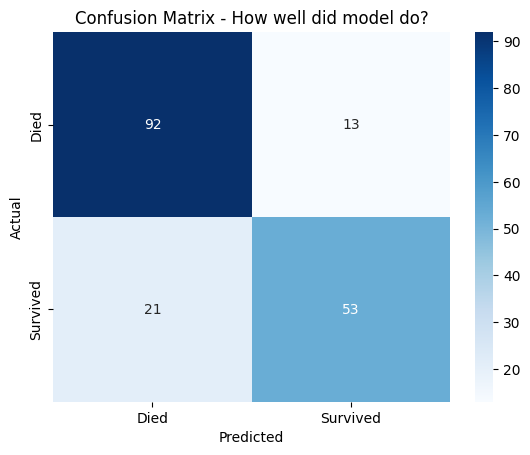

In [11]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix shows correct and wrong predictions
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died','Survived'],
            yticklabels=['Died','Survived'])
plt.title('Confusion Matrix - How well did model do?')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
## 📊 Results

| Metric | Value |
|--------|-------|
| Model | Logistic Regression |
| Training size | 712 passengers (80%) |
| Testing size | 179 passengers (20%) |
| Accuracy | 81.01% |
| Correct predictions | 145/179 |
| Wrong predictions | 34/179 |

## 🔍 Confusion Matrix Analysis
- Model correctly predicted 92 deaths ✅
- Model correctly predicted 53 survivals ✅
- Model is better at predicting death than survival
- This is because more passengers died on Titanic
  so model learned death patterns better

## 💡 Key Learnings
- ML workflow: Data→Clean→Split→Train→Test→Evaluate
- 80/20 train/test split is industry standard
- Logistic Regression works well for binary prediction
- 81% accuracy is good for a first basic model
- Model performance can be improved by adding more 
  features or using different algorithms

## 🎯 Personal Insight
My first ML model predicted Titanic survival with 81% 
accuracy. The model confirmed our earlier EDA findings — 
gender and class were the strongest survival predictors.